# Monte Carlo Pricing of European Options

In this notebook, we implement a Monte Carlo pricer for European options.

The objective is to simulate the terminal stock price under the
Black-Scholes assumptions and compare the Monte Carlo estimate
with the analytical Black-Scholes price.

## Model

Under the Black-Scholes model, the terminal stock price is:

S_T = S0 * exp((r - 0.5 σ²)T + σ√T Z)

where Z follows a standard normal distribution.

## Model

Under the Black-Scholes model, the terminal stock price is:

S_T = S0 * exp((r - 0.5 σ²)T + σ√T Z)

where Z follows a standard normal distribution.

## Monte Carlo pricing principle

1. Simulate many possible values of S_T
2. Compute the payoff for each simulation
3. Average the payoffs
4. Discount the result

Price = exp(-rT) * E[payoff]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## Theoretical framework

Under the Black-Scholes model, the stock price at maturity is given by:

S_T = S_0 * exp((r - 0.5 σ²)T + σ√T Z)

where:
- S_0 is the current stock price
- r is the risk-free rate
- σ is the volatility
- T is the time to maturity
- Z ~ N(0,1)

Once S_T is simulated, the option payoff is computed:

- Call payoff: max(S_T - K, 0)
- Put payoff: max(K - S_T, 0)

The Monte Carlo price is the discounted average payoff.

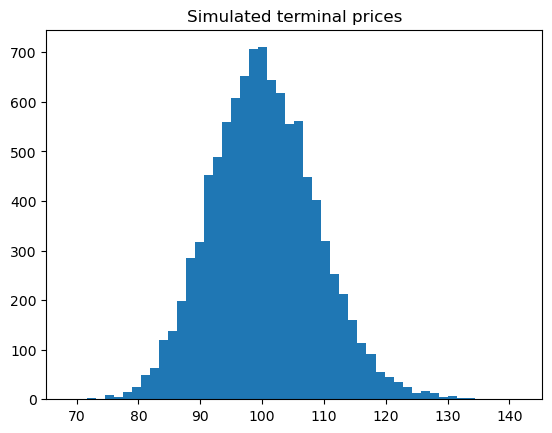

In [2]:
S0 = 100
K = 100
T = 30 / 252
r = 0.02
sigma = 0.25
N = 10000

Z = np.random.normal(size=N)

ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

plt.hist(ST, bins=50)
plt.title("Simulated terminal prices")
plt.show()

In [3]:
call_payoff = np.maximum(ST - K, 0)
put_payoff = np.maximum(K - ST, 0)

mc_call = np.exp(-r * T) * np.mean(call_payoff)
mc_put = np.exp(-r * T) * np.mean(put_payoff)

print("Call price is :",mc_call)
print("Put price is :" ,mc_put)

Call price is : 3.5518184699717428
Put price is : 3.2110108304880987


In [4]:
# Monte Carlo
def mc_call_price(S0, K, T, r, sigma, N):
    Z = np.random.normal(size=N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoff)


def mc_put_price(S0, K, T, r, sigma, N):
    Z = np.random.normal(size=N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(K - ST, 0)
    return np.exp(-r * T) * np.mean(payoff)


# Black Scholes
def d1(S, K, T, r, sigma):
    return (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma*np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    return S*norm.cdf(d1(S,K,T,r,sigma)) - K*np.exp(-r*T)*norm.cdf(d2(S,K,T,r,sigma))

def bs_put(S, K, T, r, sigma):
    return K*np.exp(-r*T)*norm.cdf(-d2(S,K,T,r,sigma)) - S*norm.cdf(-d1(S,K,T,r,sigma))



# Strike grid around ATM
strikes = [90, 95, 100, 105, 110]
results = []
for K in strikes:
    bs_c = bs_call(S0, K, T, r, sigma)
    mc_c = mc_call_price(S0, K, T, r, sigma, 10000)
    
    bs_p = bs_put(S0, K, T, r, sigma)
    mc_p = mc_put_price(S0, K, T, r, sigma, 10000)
    
    results.append({
        "Strike": K,
        "BS Call": bs_c,
        "MC Call": mc_c,
        "BS Put": bs_p,
        "MC Put": mc_p
    })

comparison_table = pd.DataFrame(results).round(4)
comparison_table

,Strike,BS Call,MC Call,BS Put,MC Put
0,90,10.6281,10.5253,0.4140,0.4133
1,95,6.5911,6.6273,1.3652,1.3632
2,100,3.5563,3.5763,3.3184,3.2955
3,105,1.6441,1.6695,6.3944,6.4149
4,110,0.6479,0.6529,10.3864,10.3822


## Comparison across strikes

We compare Monte Carlo prices with Black-Scholes prices for strike values
around the at-the-money region.

This allows us to verify that the simulation-based estimate is consistent
with the analytical benchmark.

A logarithmic scale is used on the x-axis because the number of simulations
increases by powers of 10.

This makes the convergence pattern easier to interpret.

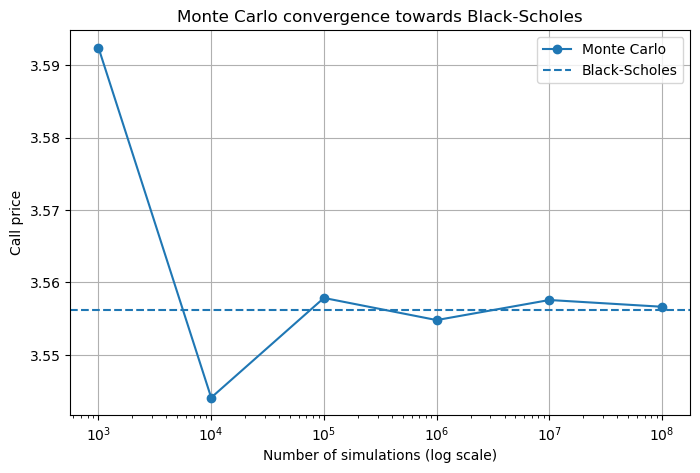

In [5]:
# Convergence test
N_values = [1000 * 10**i for i in range(6)]
convergence_results = []

for N in N_values:
    mc_price = mc_call_price(S0, 100, T, r, sigma, N)   
    convergence_results.append({
        "N simulations": N,
        "MC Call Price": mc_price,
        "BS Call Price": bs_call(S0, 100, T, r, sigma)
    })

convergence_table = pd.DataFrame(convergence_results).round(6)
convergence_table



plt.figure(figsize=(8,5))
plt.plot(convergence_table["N simulations"],convergence_table["MC Call Price"],marker="o",label="Monte Carlo")
plt.axhline(y=bs_call(S0, 100, T, r, sigma),linestyle="--",label="Black-Scholes")
plt.xscale("log")
plt.title("Monte Carlo convergence towards Black-Scholes")
plt.xlabel("Number of simulations (log scale)")
plt.ylabel("Call price")
plt.legend()
plt.grid(True)
plt.show()